# Spatial interpolation of the stage-1 residual field

The model in notebook 03 corrects each station independently. Its residual error is not spatially independent: same-hour residual correlation between neighbouring stations is approximately 0.4 and decays with distance, which is consistent with synoptically coherent forecast error such as displaced boundaries or cloud-cover errors. That component is not visible to station-local features, but it has already been measured at neighbouring stations.

This notebook adds a second stage: simple kriging of the stage-1 residual field, with a covariance fitted on the train block and applied causally, so that a row uses only residuals observed at or before its own forecast initialization time, damped for the elapsed interval.

Kriging with a fitted stationary covariance is optimal interpolation with a static background error covariance, which is tier 1 of `docs/da/DESIGN.md` applied at station locations rather than on a grid. Skill measured here is therefore an estimate of what that tier will measure.

Protocol is unchanged: split V1, covariance fitted on the train block, single evaluation of the test block.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
from scipy.optimize import curve_fit
import xgboost as xgb
import common

w = common.wide_pairs()
split = common.SPLIT_V1.label(w.forecast_valid_time)
tr, te = (split=="train").to_numpy(), (split=="test").to_numpy()
X = common.build_features(w)

m1 = xgb.XGBRegressor(); m1.load_model(common.ARTIFACTS / "t2m_correction_xgb.json")
w["stage1"] = m1.predict(X)
w["resid"] = w.err_t2m - w.stage1

# artifact integrity: the loaded model must reproduce notebook 03's stored test RMSE
stored = json.load(open(common.ARTIFACTS / "t2m_correction_metrics.json"))
stored_rmse = next(r["rmse"] for r in stored["test"] if r["method"]=="xgboost")
here = common.rmse(w.resid[te])
assert abs(here - stored_rmse) < 5e-3, (here, stored_rmse)
print(f"stage-1 test RMSE reproduced from artifact: {here:.3f} (stored {stored_rmse:.3f})")

stage-1 test RMSE reproduced from artifact: 1.612 (stored 1.612)


## 1. Covariance estimation on the train block

Spatial: train-block residual pairs at common times are binned by great-circle distance and an exponential correlogram `c0 * exp(-d / L)` is fitted. The shortfall of `c0` below 1 is the nugget, representing station-scale variance that kriging should not interpolate.

Temporal: lagged autocorrelation of station residual series is computed and `exp(-dt / tau)` is fitted. This determines the rate at which an observed error field loses predictive value.

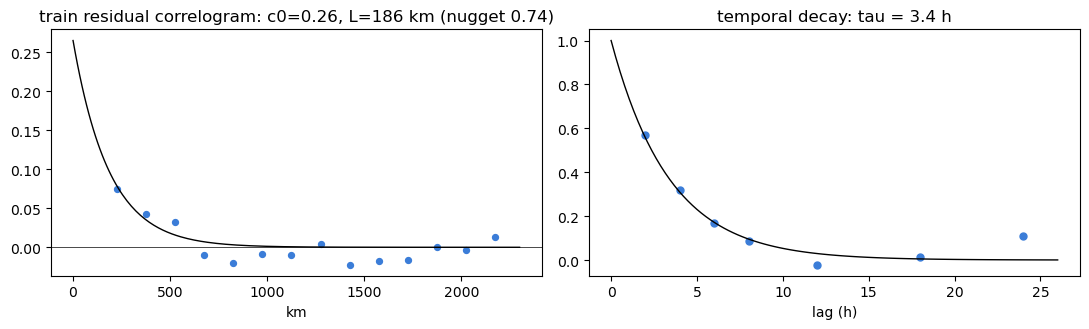

In [2]:
stns = w.groupby("station_id").agg(lat=("lat","first"), lon=("lon","first"))
S = stns.index.to_numpy()
D = common.haversine_km(stns.lat.values[:,None], stns.lon.values[:,None],
                        stns.lat.values[None,:], stns.lon.values[None,:])

piv_tr = w[tr].pivot_table(index="forecast_valid_time", columns="station_id", values="resid").reindex(columns=S)
Ccorr = piv_tr.corr(min_periods=60).values
iu = np.triu_indices_from(D, k=1)
ok = ~np.isnan(Ccorr[iu])
d_pairs, c_pairs = D[iu][ok], Ccorr[iu][ok]

bins = np.arange(0, 2400, 150)
bc, bm = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    sel = (d_pairs>=lo)&(d_pairs<hi)
    if sel.sum() >= 30: bc.append((lo+hi)/2); bm.append(c_pairs[sel].mean())
bc, bm = np.array(bc), np.array(bm)
(c0, Ls), _ = curve_fit(lambda d,c0,L: c0*np.exp(-d/L), bc, bm, p0=(0.4, 500), maxfev=5000)
sigma2 = float(piv_tr.var().mean())
nugget_frac = max(1.0 - c0, 0.05)

lag_ac = []
lags_h = np.array([2,4,6,8,12,18,24])
for lag in lags_h:
    a = piv_tr; b = piv_tr.shift(freq=pd.Timedelta(hours=int(lag)))
    joined = a.align(b, join="inner", axis=0)
    lag_ac.append(np.nanmean([joined[0][s].corr(joined[1][s]) for s in S]))
lag_ac = np.array(lag_ac)
(tau,), _ = curve_fit(lambda t,tau: np.exp(-t/tau), lags_h, lag_ac, p0=(8,), maxfev=5000)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].scatter(bc, bm, s=18, color="#3b7dd8")
dd = np.linspace(0, 2300, 200)
axes[0].plot(dd, c0*np.exp(-dd/Ls), "k-", lw=1)
axes[0].set_title(f"train residual correlogram: c0={c0:.2f}, L={Ls:.0f} km (nugget {nugget_frac:.2f})")
axes[0].set_xlabel("km"); axes[0].axhline(0, color="k", lw=.5)
axes[1].scatter(lags_h, lag_ac, s=25, color="#3b7dd8")
tt = np.linspace(0, 26, 100)
axes[1].plot(tt, np.exp(-tt/tau), "k-", lw=1)
axes[1].set_title(f"temporal decay: tau = {tau:.1f} h"); axes[1].set_xlabel("lag (h)")
plt.tight_layout(); plt.show()

## 2. Kriged fields and causal application

For each time slice in the archive, one simple kriging system is solved from the stations reporting in that slice to all 164 station locations.

Each target row uses the field from the most recent slice at or before its own `gfs_init_time`. This is the availability boundary: at initialization time those pairs existed and later ones did not. The field is then damped by `exp(-dt / tau)` for the interval between the slice and the row's valid time.

Separating the spatial solve from the temporal damping is an approximation to full space-time kriging, adopted here for tractability and legibility.

In [3]:
def kriged_fields(resid_col, obs_mask):
    """slice time -> kriged residual vector at all stations, using only
    rows flagged by obs_mask as the observing network."""
    pv = (w[obs_mask].pivot_table(index="forecast_valid_time", columns="station_id",
                                  values=resid_col).reindex(columns=S))
    fields = {}
    for t, row in pv.iterrows():
        has = ~row.isna().values
        if has.sum() < 20: continue
        Co = sigma2 * ((1-nugget_frac)*np.exp(-D[np.ix_(has,has)]/Ls) + nugget_frac*np.eye(has.sum()))
        Ct = sigma2 *  (1-nugget_frac)*np.exp(-D[:,has]/Ls)
        Wgt = np.linalg.solve(Co, Ct.T)              # (n_obs, 164)
        fields[t] = row.values[has] @ Wgt
    return fields

def apply_kriging(fields):
    """per-row damped kriged residual, using only slices <= the row's init time.
    All time comparisons in int64 UTC nanoseconds - mixing tz-aware pandas
    Timestamps with numpy datetime64 inside searchsorted raises."""
    times = sorted(fields.keys())
    times_ns = np.array([t.value for t in times])
    stacked = np.vstack([fields[t] for t in times])
    sidx = pd.Index(S).get_indexer(w.station_id)
    init_ns  = w.gfs_init_time.astype("int64").to_numpy()
    valid_ns = w.forecast_valid_time.astype("int64").to_numpy()
    pos = np.searchsorted(times_ns, init_ns, side="right") - 1
    out = np.zeros(len(w))
    ok = pos >= 0
    dt_h = (valid_ns - times_ns[np.clip(pos, 0, None)]) / 3.6e12
    out[ok] = np.exp(-dt_h[ok]/tau) * stacked[pos[ok], sidx[ok]]
    return out

fields = kriged_fields("resid", np.ones(len(w), bool))
w["krige"] = apply_kriging(fields)
dth = (w.forecast_valid_time - w.gfs_init_time).dt.total_seconds()/3600
print(f"slices kriged: {len(fields)}   median damping factor on test: "
      f"{np.median(np.exp(-dth[te]/tau)):.2f}")

slices kriged: 458   median damping factor on test: 0.56


## 3. Test-block evaluation

The second row is the quantity of interest. The third and fourth rows apply the same kriging step to the per-station offset instead of to the stage-1 residual, to test whether the spatial term is recovering error the learned model has already removed.

In [4]:
rows = {
 "stage-1 alone (nb 03)":            common.rmse(w.resid[te]),
 "stage-1 + kriged residual":        common.rmse((w.resid - w.krige)[te]),
}
# ablation: is kriging only recovering what stage-1 already knew? apply it to a dumb stage 1
so = w.err_t2m - w[tr].groupby(w[tr].station_id).err_t2m.mean().reindex(w.station_id).fillna(w.err_t2m[tr].mean()).values
w["resid_so"] = so
f2 = kriged_fields("resid_so", np.ones(len(w), bool))
w["krige_so"] = apply_kriging(f2)
rows["station_offset alone (nb 02)"] = common.rmse(w.resid_so[te])
rows["station_offset + kriged residual"] = common.rmse((w.resid_so - w.krige_so)[te])
tbl = pd.Series(rows, name="test RMSE (°C)").round(3).to_frame()
tbl

,test RMSE (°C)
stage-1 alone (nb 03),1.612
stage-1 + kriged residual,1.469
station_offset alone (nb 02),2.031
station_offset + kriged residual,1.842


## 4. Interpolation to stations with no history

Kriging of the raw error field from the approximately 80% of stations designated as observing, evaluated at the withheld 20% (`common.is_withheld`). No learned model and no per-station history are used, so any skill measured here is attributable to the neighbour observations and the fitted covariance alone. This is the configuration corresponding to gridded analysis at locations without a gauge.

In [5]:
wh = w.station_id.map(common.is_withheld).to_numpy()
f3 = kriged_fields("err_t2m", ~wh)                 # observe only non-withheld stations
w["krige_raw"] = apply_kriging(f3)
mt = te & wh
pd.Series({
  "raw forecast": common.rmse(w.err_t2m[mt]),
  "+ kriged neighbor errors (no ML, no history)": common.rmse((w.err_t2m - w.krige_raw)[mt]),
}, name="test RMSE at withheld stations (°C)").round(3).to_frame()

,test RMSE at withheld stations (°C)
raw forecast,2.375
"+ kriged neighbor errors (no ML, no history)",2.270


## 5. Example slice

Station residuals for one time slice, and the corresponding kriged field.

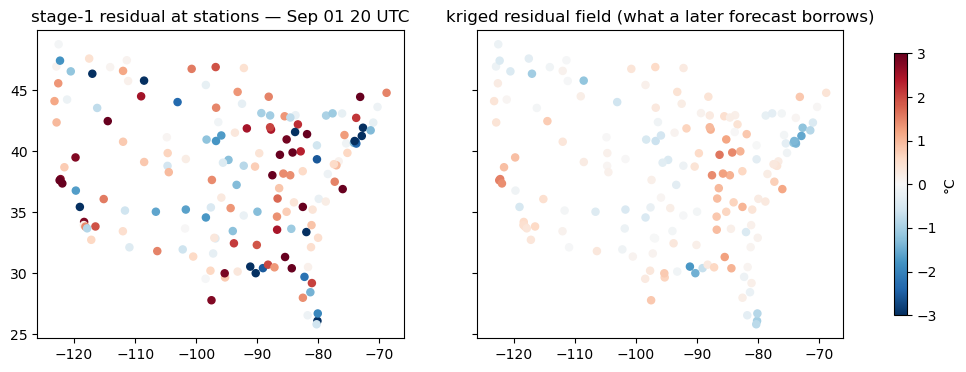

In [6]:
slice_ts = sorted(t for t in fields if (t.date().isoformat() >= "2026-08-30" and t.hour in (18,20)))
t0 = slice_ts[-1]
obs_slice = w[w.forecast_valid_time == t0].set_index("station_id")
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
v = 3
sc0 = axes[0].scatter(obs_slice.lon, obs_slice.lat, c=obs_slice.resid, cmap="RdBu_r", vmin=-v, vmax=v, s=26)
axes[0].set_title(f"stage-1 residual at stations — {t0:%b %d %H UTC}")
sc1 = axes[1].scatter(stns.lon, stns.lat, c=fields[t0], cmap="RdBu_r", vmin=-v, vmax=v, s=26)
axes[1].set_title("kriged residual field (what a later forecast borrows)")
for ax in axes: ax.set_xlim(-126, -66)
plt.colorbar(sc1, ax=axes, label="°C", shrink=0.85)
plt.show()

## Summary

Test-block results:

| configuration | test RMSE (°C) |
|---|---|
| raw GFS | 2.255 |
| station offset (notebook 02) | 2.031 |
| stage-1 XGBoost (notebook 03) | 1.612 |
| stage-1 with kriged residual | 1.469 |

1. The spatial stage removes a further 9% of RMSE after the pointwise model, giving a total reduction of 35% relative to raw GFS.
2. The two stages remove distinct error components. Kriging applied to the per-station offset reaches only 1.842 °C, so neither stage subsumes the other.
3. The median temporal damping factor on the test block is 0.56, indicating that approximately half the observed error signal is retained across the interval between initialization and valid time. A shorter interval retains more, which is a property of the 6-hourly DA cycle where the background is valid at analysis time.
4. At the 35 withheld stations, interpolating the raw error field from neighbours alone reduces RMSE from 2.375 to 2.270 °C. The effect is small but is obtained without any per-station history, by the fitted covariance alone.

Method limitations: the covariance is stationary and isotropic, using a single length scale across all terrain; the space-time structure is treated as separable; and the correlogram is fitted to five warm-season weeks. These are the standard limitations of a static background error covariance. The flow-dependent alternative is the ensemble square-root filter, which is the next tier of the DA design and is not addressed here.

Deployment form: the XGBoost artifact together with one kriging solve per refresh cycle, with the fitted parameters (`c0`, `L`, nugget, `tau`) versioned alongside the model. Interval calibration from notebook 03 remains a precondition for any user-facing change.